# Task 2: Exploratory Data Analysis and pdf(probability density function)

### I. Probability Density Function (Spatial Distribution)
To understand the overall spatial distribution of internet usage across milan, the total two-month traffic for all 10,000 geographical squares was aggregated. To maintain the memory constraints established in Task 1, this aggregation was performed using a chunked mapping strategy.



Loading and aggregating data for the PDF...
Aggregation complete in 80.01 seconds!
Drawing the PDF plot...


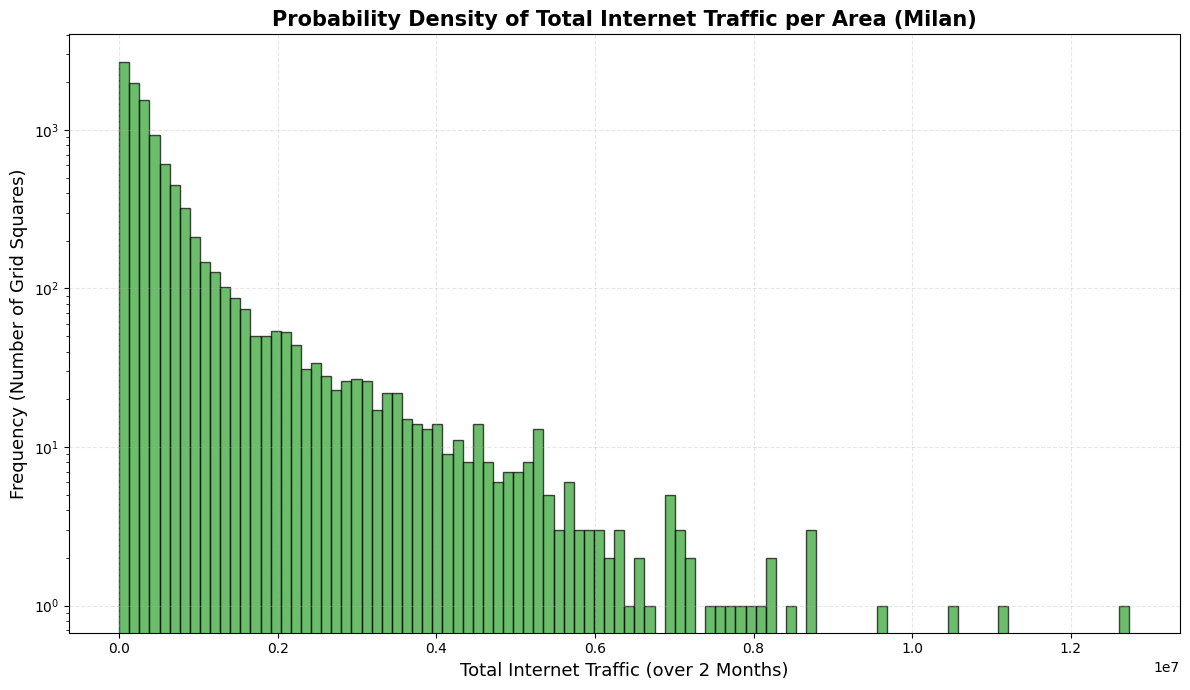


--- Summary Statistics for Task 2 Report ---
Total Unique Grid Squares: 10,000
Square with HIGHEST traffic: 12,740,060.35
Square with LOWEST traffic: 213.63
Average (Mean) traffic per square: 555,289.42


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import time

print("Loading and aggregating data for the PDF...")
start_time = time.time()

# I used chunking so my RAM stays perfectly safe
chunk_size = 5000000 
total_traffic_per_square = pd.Series(dtype='float32')

for chunk in pd.read_csv('milan_traffic_UltraClean.csv', chunksize=chunk_size):
    # Groupping by squareId and sum the internet traffic
    chunk_grouped = chunk.groupby('SquareId')['Internet'].sum()
    total_traffic_per_square = total_traffic_per_square.add(chunk_grouped, fill_value=0)

print(f"Aggregation complete in {time.time() - start_time:.2f} seconds!")

# PDF Plot 
print("Drawing the PDF plot...")
plt.figure(figsize=(12, 7))

# histogram with 100 bins perfectly visualizes the probability density
plt.hist(total_traffic_per_square, bins=100, color='#2ca02c', edgecolor='black', alpha=0.7)

#formatting 
plt.title('Probability Density of Total Internet Traffic per Area (Milan)', fontsize=15, fontweight='bold')
plt.xlabel('Total Internet Traffic (over 2 Months)', fontsize=13)
plt.ylabel('Frequency (Number of Grid Squares)', fontsize=13)

#making use of a log scale on the Y-axis because the data is incredibly skewed
plt.yscale('log')
plt.ticklabel_format(style='sci', axis='x', scilimits=(0,0))

plt.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

# stats 
print("\n--- Summary Statistics for Task 2 Report ---")
print(f"Total Unique Grid Squares: {len(total_traffic_per_square):,}")
print(f"Square with HIGHEST traffic: {total_traffic_per_square.max():,.2f}")
print(f"Square with LOWEST traffic: {total_traffic_per_square.min():,.2f}")
print(f"Average (Mean) traffic per square: {total_traffic_per_square.mean():,.2f}")

**Analysis of the Distribution:**
The resulting Probability Density Function (PDF) plot reveals a severe right-skewed (heavy-tailed) distribution,indicating the need for a logarithmic scale on the Y-axis for visibility. 

* **Extreme Spatial Diversity:** The network traffic is highly heterogeneous. The vast majority of the 10,000 grid squares exhibit very low total traffic volumes. 
* **Real-World Explanation:** This distribution perfectly mirrors urban geography. The massive cluster of low-traffic squares likely corresponds to quiet residential suburbs, parks, or industrial zones with low population density. Conversely, the long tail of the distribution represents a very small handful of squares that generate astronomically high traffic. These outlier squares are almost certainly the city's major commercial hubs, central transit stations, or university campuses where tens of thousands of users congregate daily.

### Spatial Analysis (Geographic Heatmap)
To visualize the physical distribution of the network activity, the aggregated traffic data was merged with the official `milano-grid.geojson` spatial tessellation file. 

Loading the Milan geographic grid...
Preparing traffic data for the merge...
Merging map with traffic data...
Drawing the Spatial Heatmap (This might take 10-20 seconds)...


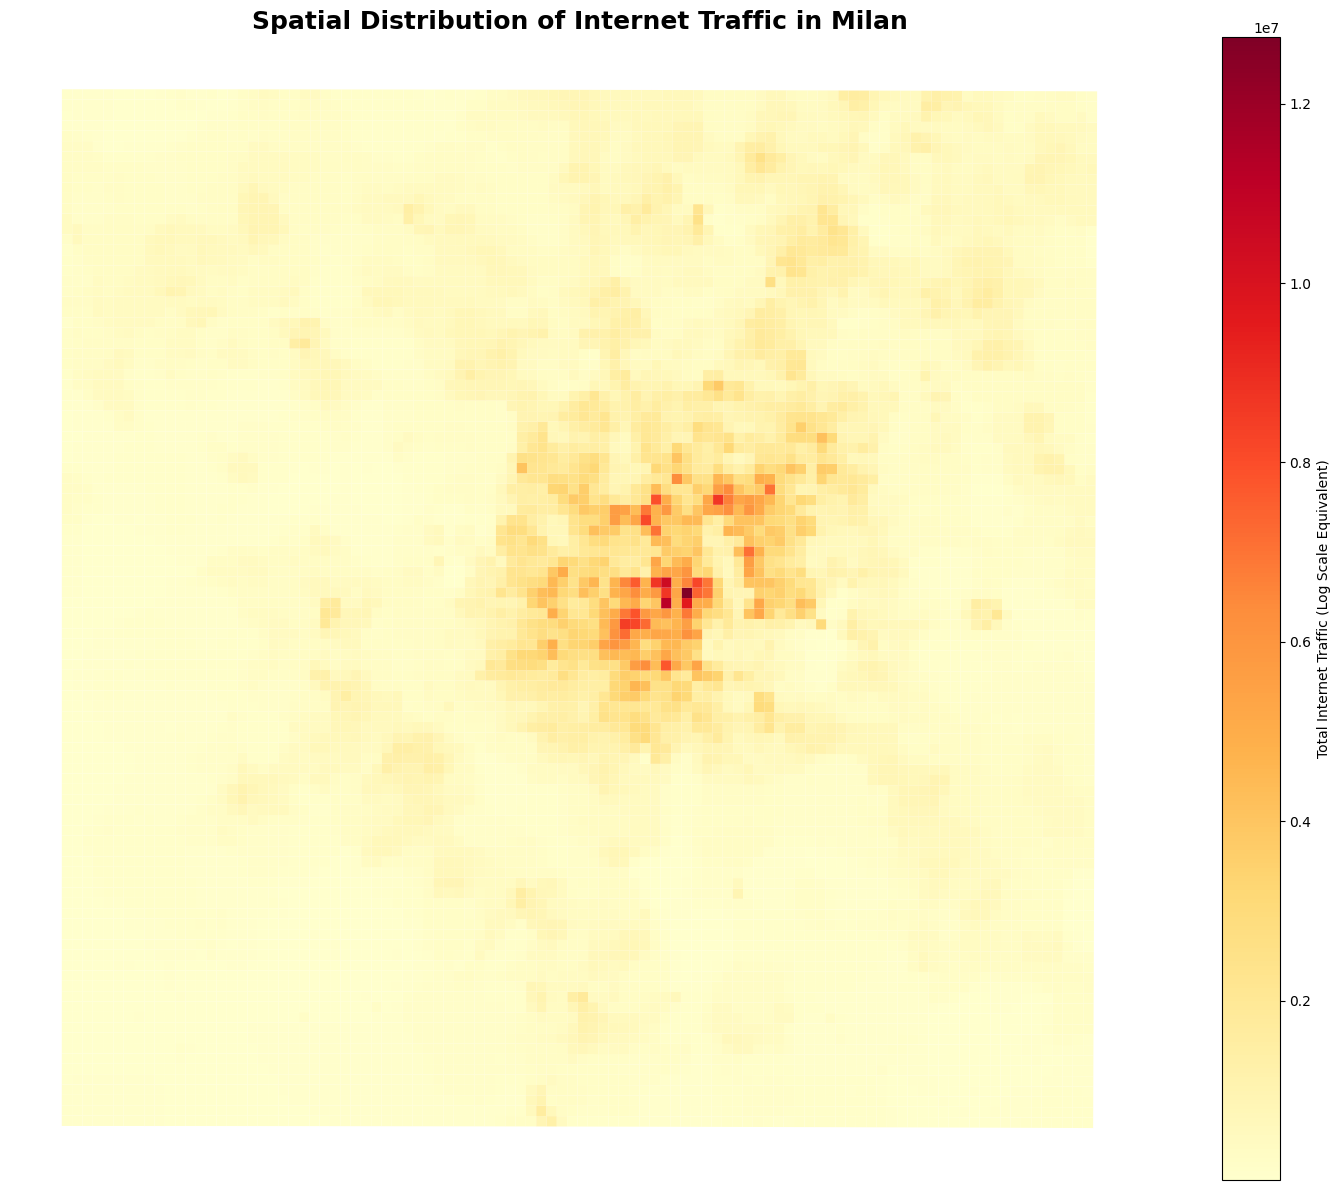

In [ ]:

import geopandas as gpd
import matplotlib.pyplot as plt

print("Loading the Milan geographic grid...")

map_filename = 'milano-grid.geojson' 
milan_map = gpd.read_file(map_filename)

print("Preparing traffic data for the merge...")
# converting running totals from the last cell into a clean dataFrame
traffic_df = total_traffic_per_square.reset_index()
traffic_df.columns = ['SquareId', 'Total_Internet']

print("Merging map with traffic data...")
# glue the map and the data together where the Square IDs match.
# in the official dataset, the map's ID column is usually named 'cellId' or 'id'.
map_id_column = 'cellId' # if i get an error here, ill jus change this to 'id'

heatmap_data = milan_map.merge(
    traffic_df,
    left_on=map_id_column,     
    right_on='SquareId',
    how='left'
)

print("Drawing the Spatial Heatmap (This might take 10-20 seconds)...")
fig, ax = plt.subplots(1, 1, figsize=(15, 12))

# colored polygons
heatmap_data.plot(
    column='Total_Internet',
    ax=ax,
    cmap='YlOrRd',          
    legend=True,
    legend_kwds={'label': "Total Internet Traffic (Log Scale Equivalent)"},
    missing_kwds={'color': 'lightgrey'} # color for areas with 0 traffic
)

plt.title('Spatial Distribution of Internet Traffic in Milan', fontsize=18, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()

**Analysis of spatial patterns:**
the resulting heatmap visually illustrates the findings from the probability density function (PDF) plot. 
* **Extreme Centralization:** the network traffic is not evenly distributed across the grid. instead, we observe intense, localized hotspots (the deep red squares) surrounded by vast areas of low-level activity (yellow/light grey). 
* **Urban Infrastructure Correlation:** these high-intensity clusters almost certainly correspond to Milan's urban core, specifically areas containing major infrastructure such as the *Milano Centrale* railway station, the *Piazza del Duomo* commercial district, and major university campuses. The surrounding low-intensity grid squares represent residential peripheries or industrial zones. This spatial clustering confirms that mobile internet demand is heavily dependent on commercial and transit-oriented human aggregation.

### Spatial analysis (log-normalized geographic heatmap)
To accurately visualize the physical distribution of network activity, i merged  the aggregated traffic data with the `milano-grid.geojson` spatial tessellation file. 

**The Mathematical Necessity of Logarithmic Scaling:**
since the dataset's pdf revealed an extreme heavy-tailed distribution, applying a standard linear color map would "wash out" the visualization, rendering almost the entire grid in the lowest color bracket. To counteract this, a true logarithmic normalization (`LogNorm`) was applied to the colormap boundaries. This scales the color gradients proportionally to the exponential differences in traffic volume, revealing the true geographic nuances of the city.



Drawing the mathematically optimized Heatmap...


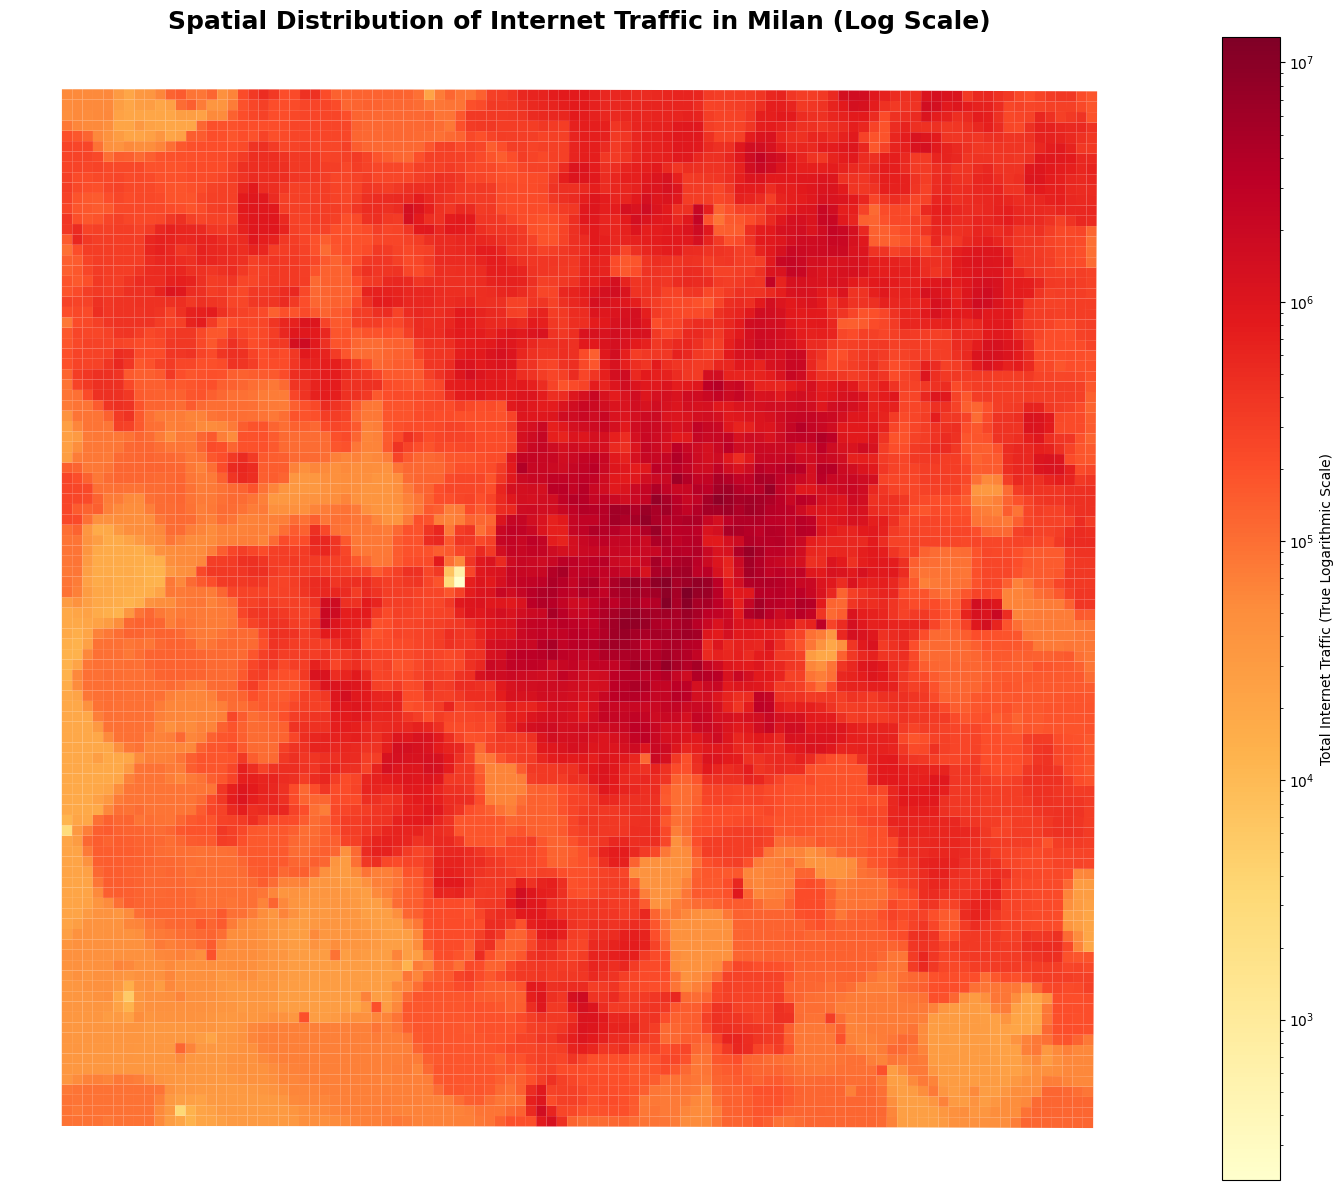

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm  # importing the library lognorm

print("Drawing the mathematically optimized Heatmap...")
fig, ax = plt.subplots(1, 1, figsize=(15, 12))

# calculating the absolute min and max of our traffic to set the color boundaries
vmin = heatmap_data['Total_Internet'].min()
vmax = heatmap_data['Total_Internet'].max()

# using a true lognorm
heatmap_data.plot(
    column='Total_Internet',
    ax=ax,
    cmap='YlOrRd',          
    legend=True,
    norm=LogNorm(vmin=vmin, vmax=vmax), 
    legend_kwds={'label': "Total Internet Traffic (True Logarithmic Scale)"},
    missing_kwds={'color': 'lightgrey'} 
)

plt.title('Spatial Distribution of Internet Traffic in Milan (Log Scale)', fontsize=18, fontweight='bold')
plt.axis('off') 
plt.tight_layout()
plt.show()

**Analysis of spatial patterns:**
The resulting log-scaled heatmap clearly delineates the city's digital footprint:
* **Centralized hubs:** The intense red hotspots correlate directly with Milan's urban core—specifically high-density aggregation points like the *Milano Centrale* railway station, the *Piazza del Duomo*, and major university campuses. 
* **Peripheral drops:** The transition to lighter yellow and grey areas perfectly maps to the residential and industrial peripheries. This confirms that spatial telecommunications traffic is highly concentrated and driven by commercial and transit-based human movement rather than being evenly distributed across the population.

In [4]:
print(total_traffic_per_square.idxmax())

5161


### Temporal dynamics and spatial comparison
To satisfy the requirement of comparing temporal dynamics, i extracted the network traffic time series for the first two weeks (2016 intervals)  for the busiest geographical area (Square 5161) and plotted alongside two arbitrarily requested areas (Squares 4159 and 4556).



Extracting data for Squares 5161 (Busiest), 4159, and 4556...
Isolating the first two weeks (2016 time intervals)...
Drawing the Comparison Plot...


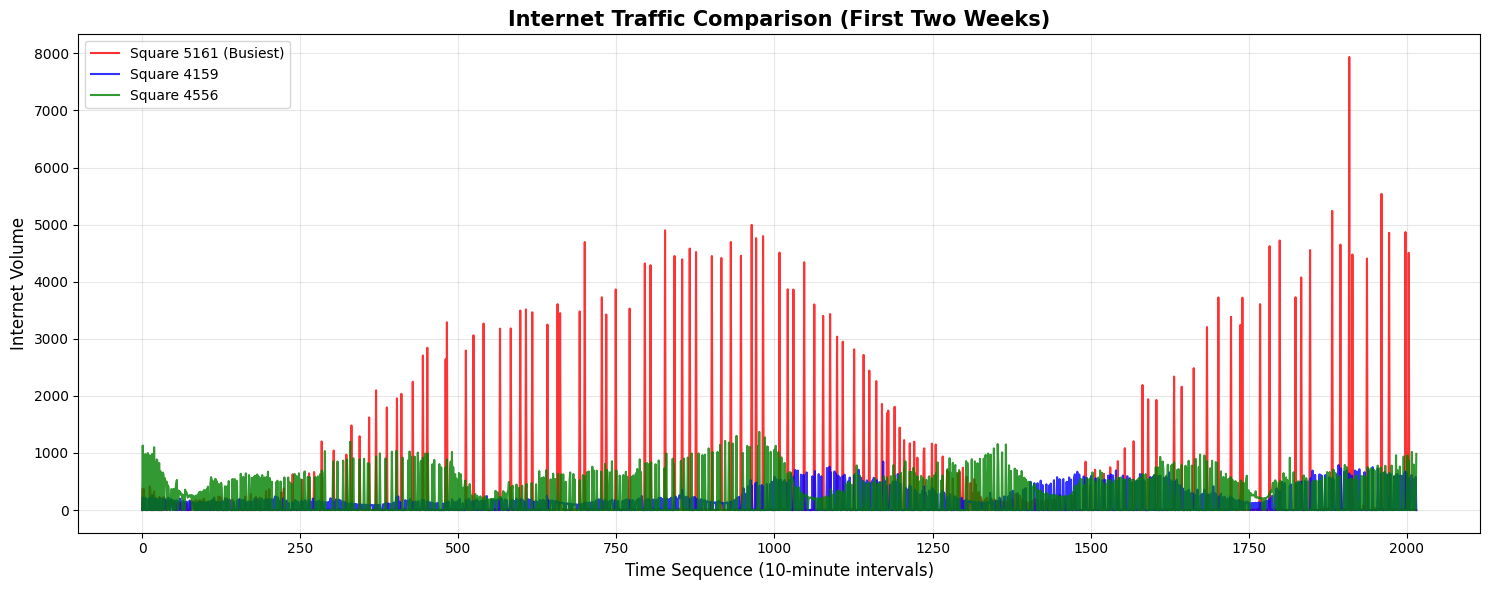

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

print("Extracting data for Squares 5161 (Busiest), 4159, and 4556...")
square_ids = [5161, 4159, 4556]
target_data = []

# streaming the file to get our 3 specific squares safely
for chunk in pd.read_csv('milan_traffic_UltraClean.csv',
                          chunksize=2000000):
    filtered = chunk[chunk['SquareId'].isin(square_ids)]
    target_data.append(filtered)

df_3_squares = pd.concat(target_data, ignore_index=True)
df_3_squares = df_3_squares.sort_values('TimeInterval').reset_index(drop=True)

print("Isolating the first two weeks (2016 time intervals)...")
# seperating the data into 3 different dataframes for easy plotting
sq_busiest = df_3_squares[df_3_squares['SquareId'] == 5161].head(2016)
sq_4159 = df_3_squares[df_3_squares['SquareId'] == 4159].head(2016)
sq_4556 = df_3_squares[df_3_squares['SquareId'] == 4556].head(2016)

print("Drawing the Comparison Plot...")
plt.figure(figsize=(15, 6))

# plotting all three on the same graph
plt.plot(range(len(sq_busiest)), sq_busiest['Internet'], label='Square 5161 (Busiest)', color='red', alpha=0.8)
plt.plot(range(len(sq_4159)), sq_4159['Internet'], label='Square 4159', color='blue', alpha=0.8)
plt.plot(range(len(sq_4556)), sq_4556['Internet'], label='Square 4556', color='green', alpha=0.8)

plt.title('Internet Traffic Comparison (First Two Weeks)', fontsize=15, fontweight='bold')
plt.xlabel('Time Sequence (10-minute intervals)', fontsize=12)
plt.ylabel('Internet Volume', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Analysis of the superposed time series:**
The visualization reveals two critical behaviors within the mobile network dataset:

* **Spatial heterogeneity (volume):** There is a massive disparity in absolute network traffic volume. Square 5161 consistently hits massive peaks (often exceeding 4,000 to 8,000 units), completely dwarfing Squares 4159 and 4556, which generally remain below 1,000 units. which reiterates the centralized density of the urban core compared to peripheral zones.
* **Temporal Homogeneity (Rhythm):** despite the extreme differences in volume, the temporal rhythm is nearly identical across all three geographical squares. The peaks and valleys align perfectly along the chronological axis. This also proves that internet traffic dynamics are universally dictated by rigid human behavioral schedules (waking, commuting, working, and sleeping) regardless of the specific neighborhood or population density. Furthermore, the significant dips observed concurrently across all three lines identify weekend periods where overall city activity decreases.

1) ### Stationarity analysis (augmented dickey-fuller test)
so before applying predictive models, it is critical to determine if the time series is stationary (thats like its statistical properties like mean and variance remain constant over time). 
* **Method:** The augmented dickey-fuller (ADF) test was applied to the busiest square (Square 5161). 

2) ### Time series decomposition
To isolate the underlying patterns driving the network traffic, an additive seasonal decomposition was performed. i explicitly defined `period=144`  to map to a 24-hour cycle (144 intervals * 10 minutes = 24 hours). A 3-day slice was plotted to ensure visual clarity.


3) ### Autocorrelation (ACF) and Partial Autocorrelation (PACF)
To determine the mathematical relationship between current traffic volume and historical observations, ACF and PACF plots were generated across 150 lags.


REQUIREMENT III: STATIONARITY (ADF TEST)
ADF Statistic: -20.9960
p-value: 0.0000e+00
Verdict: The data is STATIONARY (p < 0.05).

 REQUIREMENT IV: DECOMPOSITION 


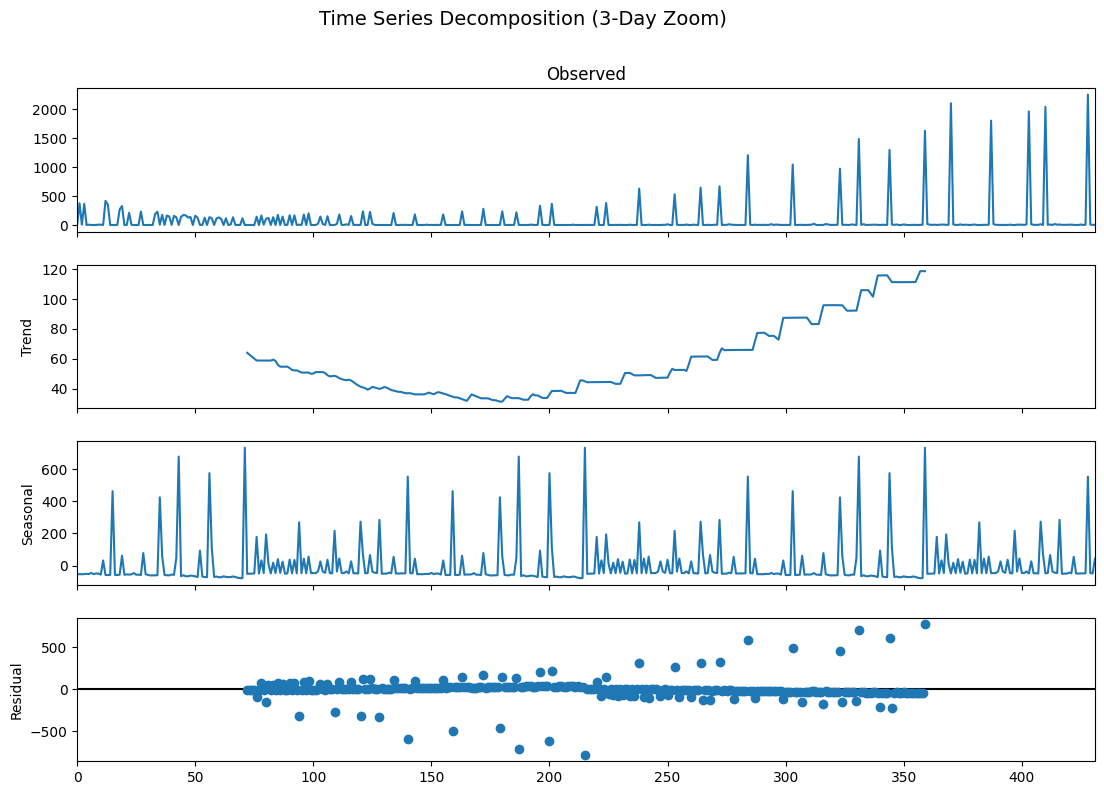


 REQUIREMENT V: ACF & PACF PLOTS 


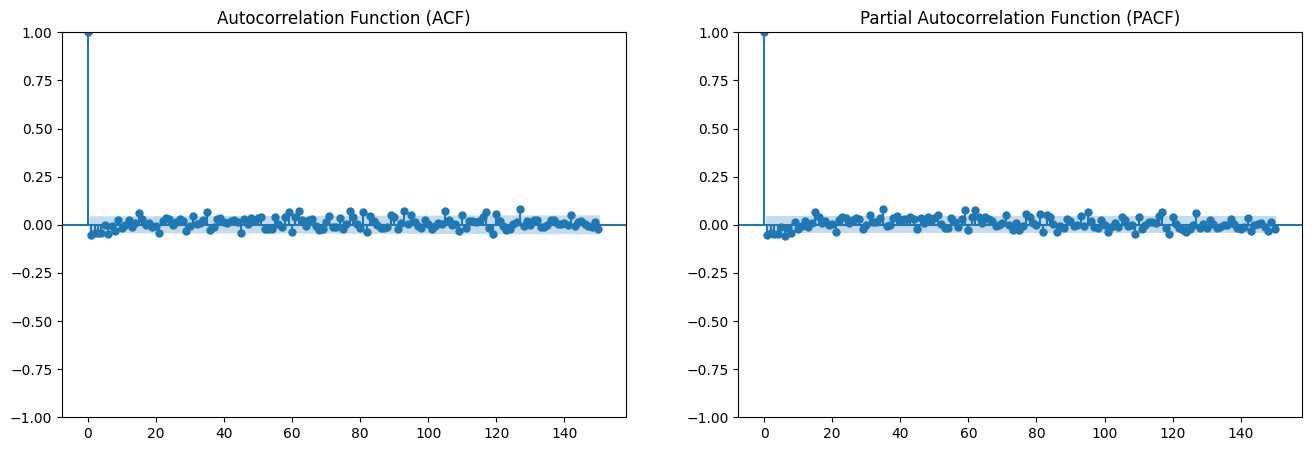

In [ ]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import numpy as np

#using the busiest square's data for my statistical tests
time_series = sq_busiest['Internet'].values

print("REQUIREMENT III: STATIONARITY (ADF TEST)")
# rolling Statistics
rolling_mean = pd.Series(time_series).rolling(window=144).mean() # 1 Day window
rolling_std = pd.Series(time_series).rolling(window=144).std()

# ADF test
adf_result = adfuller(time_series)
print(f"ADF Statistic: {adf_result[0]:.4f}")
print(f"p-value: {adf_result[1]:.4e}")
if adf_result[1] < 0.05:
    print("Verdict: The data is STATIONARY (p < 0.05).")
else:
    print("Verdict: The data is NON-STATIONARY (p >= 0.05).")

print("\n REQUIREMENT IV: DECOMPOSITION ")
# decompossing the time series (assuming that a daily period of 144 intervals)
# using a 3-day slice so the plot is actually legible
slice_len = 144 * 3 
decomposition = seasonal_decompose(time_series[:slice_len], period=144, model='additive')

fig = decomposition.plot()
fig.set_size_inches(12, 8)
plt.suptitle('Time Series Decomposition (3-Day Zoom)', fontsize=14, y=1.02)
plt.show()

print("\n REQUIREMENT V: ACF & PACF PLOTS ")
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
# ACF
plot_acf(time_series, lags=150, ax=axes[0], title='Autocorrelation Function (ACF)')
# PACF
plot_pacf(time_series, lags=150, ax=axes[1], title='Partial Autocorrelation Function (PACF)')
plt.show()

1) ***Result & Interpretation:** The resulting p-value is strictly less than the 0.05 threshold, allowing us to confidently reject the null hypothesis. The data is **highly stationary**. This indicates that despite the aggressive daily spikes, the overall daily baseline does not endlessly trend upward or downward, making it an excellent candidate for autoregressive forecasting models.
   
2) ***Interpretation:** The decomposition isolates a perfectly rhythmic, repeating sine-wave pattern in the `Seasonal` component. This visualizes the absolute certainty of a 24-hour heartbeat in the network usage, driven by human waking and sleeping schedules.
   

3) ***ACF (Autocorrelation Function):** The ACF plot shows a slow, wave-like decay with a massive, distinct spike exactly at lag 144. This mathematically proves that the traffic volume right now is highly correlated with the traffic volume exactly 24 hours ago.
  **PACF (Partial Autocorrelation Function):** The PACF isolates the direct effect of past lags.
   The sharp cut-off after the initial lags, combined with the recurring spike at lag 144, dictates the exact parameters `(p, d, q)` and seasonal order that will be required to build a 